## Método de Newton-Rhapson

$$
    x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
$$

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def newton_rhapson( f, fp, x0, tol=1e-5, maxiters = 300 ):
    hist = [ x0 ]

    for i in range(maxiters):
        xn = x0 - f(x0)/fp(x0)
        x0 = xn
        hist.append(x0)

        if abs(f(x0)) < tol:
            break

    return x0, hist

In [5]:
f = lambda x: np.sin(x)
fp = lambda x: np.cos(x)

xc, hist = newton_rhapson(f, fp, 1.0 )

In [6]:
hist

[1.0,
 np.float64(-0.5574077246549021),
 np.float64(0.06593645192484066),
 np.float64(-9.572191932508134e-05),
 np.float64(2.923566201412306e-13)]

## Ecuación de la trayectoria del movimiento bi-dimensional

$$
    y = \tan(\theta) x - \frac{g}{2 v_0^2 \cos(\theta)^2} x^2
$$

El problema de búsqueda de raíces se escribe como:
$$
    0 =  \tan(\theta) X - \frac{g}{2 v_0^2 \cos(\theta)^2} X^2 - Y
$$

$X=12$ m, $Y=5$ m, $v_0 = 20 \ \text{m}/s^2$

In [42]:
X = 12.0
Y = 5.0
v0 = 20.0
g = 9.8

f = lambda th: np.tan(th)*X - g/(2*v0**2*np.cos(th)**2)*X**2 - Y
fp = lambda th: 1/np.cos(th)**2*( X - 2*g/(2*v0**2)*X**2*np.tan(th) )

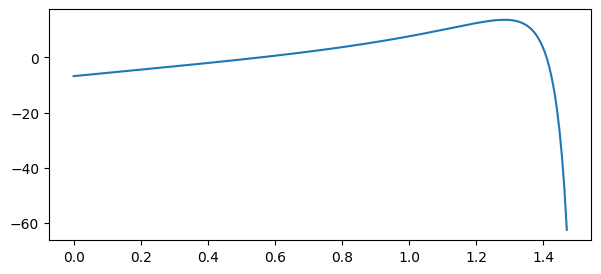

In [60]:
x = np.linspace(0, np.pi/2-0.1, 200)
plt.figure(figsize=(7,3))
plt.plot(x, f(x))
plt.show()

In [61]:
xc, hist = newton_rhapson(f,fp,0.4)

In [62]:
print( f" El ángulo mínimo es {xc*180/np.pi}")

 El ángulo mínimo es 31.80769188532193


Trayectoria del proyectil para el ángulo mínimo

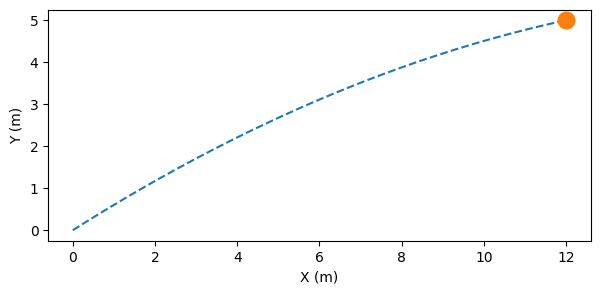

In [71]:
x = lambda t: v0*np.cos(xc)*t
y = lambda t: v0*np.sin(xc)*t - 0.5*g*t**2

tf = X/(v0*np.cos(xc))
t = np.linspace(0, tf, 200)
plt.figure(figsize=(7,3))
plt.plot( x(t), y(t), "--" )
plt.plot( [X], [Y],"o", ms=12 )
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()

In [64]:
h = 1e-4
_fp = lambda th: (f(th + h) - f(th - h))/(2*h)

comparación entre la derivada numérica y analítica

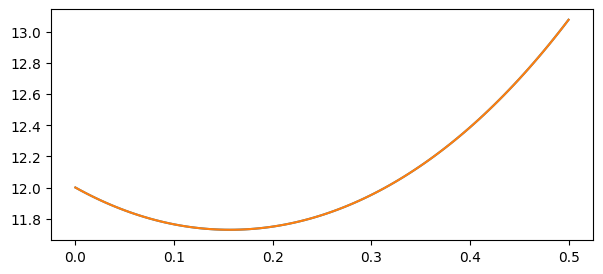

In [65]:
x = np.linspace(0, 0.5, 100)
plt.figure(figsize=(7,3))
plt.plot(x,fp(x))
plt.plot(x,_fp(x))
plt.show()

Búsqueda de raíz usando el método de Newton-Rhapson y la derivada númerica

In [67]:
xc, hist = newton_rhapson(f,_fp,0.4)

In [69]:
print( f" El ángulo mínimo es {xc*180/np.pi}")

 El ángulo mínimo es 31.807691885325987
